In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

import numpy as np

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359
maxval=1e9
minval=1e-9

2026-01-09 03:05:17.731809: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767924317.939364     376 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767924318.011595     376 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767924318.611533     376 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767924318.611562     376 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767924318.611564     376 computation_placer.cc:177] computation placer alr

In [2]:
# # os.chdir('SmartPix/data_generator')
os.chdir('/home/das214/SmartPix/SoftQuantize')
!pwd

/home/das214/SmartPix/SoftQuantize


In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.AnnealingScheduler import AnnealingScheduler
from models.models import CreateModel # Conv2D model

In [4]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"
# dataset_base_dir = '/depot/cms/users/das214/datasets/temporary/preamp_response/'
print(os.listdir(dataset_base_dir))

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t_N_0.0mu_80.0sig_NoLog_Stdr")
print(os.listdir(os.path.join(dataset_base_dir, "TFR_files")))
print(os.listdir(tfrecords_base_dir))

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

['train', 'test', 'TFR_files']
['2t_N_0.0mu_80.0sig_NoLog_Stdr', '2t_N_0.0mu_80.0sig', '2t_N_0.0mu_400.0sig', 'TRanf2_2t_N_0.0mu_80.0sig']
['TFR_val', 'TFR_train']


In [5]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=True,
    seed=42,
    quantize=False,
)

print("num train batches:", len(training_generator))
print("num val batches  :", len(validation_generator))

b = 0
X, y = training_generator[b]
X = X.numpy()
y = y.numpy()

print("X shape:", X.shape, "dtype:", X.dtype)   # expect (B, H, W, C) or similar
print("y shape:", y.shape, "dtype:", y.dtype)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/metadata.json


Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/metadata.json


2026-01-09 03:06:49.167679: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


num train batches: 84
num val batches  : 21
X shape: (5000, 16, 16, 2) dtype: float32
y shape: (5000, 4) dtype: float32


2026-01-09 03:06:49.644604: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144


In [6]:
# Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
# Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
# Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16

In [53]:
def create_quantizer_model(input_shape, initial_thresholds, threshold_offset):
    inp = layers.Input(shape=input_shape, name="raw_input")
    q_out = SoftQuantizeLayer(
        n_bits=2,
        initial_levels=np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32),
        threshold_offset=threshold_offset,
        initial_thresholds=initial_thresholds,
        trainable_levels=False,
        trainable_thresholds=True,
        initial_k=1.0,
        trainable_k=True,
        name="soft_quantizer_output"
    )(inp)
    return keras.Model(inputs=inp, outputs=q_out, name="quantizer")

quantizer_model = create_quantizer_model(
    input_shape=(16,16,2),
    initial_thresholds=[249.30, 667.66, 1659.27],
    threshold_offset=80.0
)

In [54]:
b = 0
X, y = training_generator[b]

print("X shape:", X.shape, "dtype:", X.dtype) 
print("y shape:", y.shape, "dtype:", y.dtype)

X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
Q_tf = quantizer_model(X_tf, training=False)     # hard quantize
Q_int = np.rint(Q_tf).astype(np.int8)
u = np.unique(Q_int)
print("Unique values in Q_int:", u)
assert u.min() >= 0 and u.max() <= 3, "Q_int has values outside {0,1,2,3}."
Q = Q_int

print("Q:", Q.shape, Q.dtype)
print("Unique values in Q (sample):", np.unique(Q[: min(200, Q.size)]))

X shape: (5000, 16, 16, 2) dtype: <dtype: 'float32'>
y shape: (5000, 4) dtype: <dtype: 'float32'>
Unique values in Q_int: [0 1 2 3]
Q: (5000, 16, 16, 2) int8
Unique values in Q (sample): [0 1 2 3]


# Patch Analysis

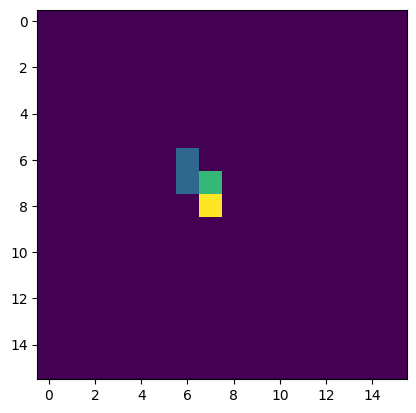

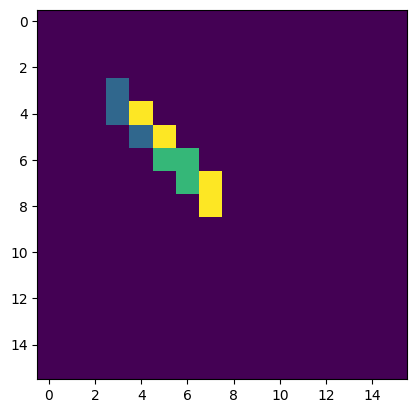

In [55]:
plt.imshow(Q[0, :, :, 0])
plt.show()

plt.imshow(Q[0, :, :, 1])
plt.show()

In [56]:
from collections import Counter

def extract_patches(Q, patch_dim, stride=None):
    """
    Q: (B,H,W,C) with discrete values in {0,1,2,3} (or floats very close to those)
    patch_dim: (pH,pW)
    stride: (dY,dX) or None -> non-overlapping
    Returns: list of patch tuples (flattened) over (b,c,y,x) tiles.
    """
    B, H, W, C = Q.shape
    pH, pW = patch_dim
    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride

    patches_ctr = Counter()
    for b in range(B):
        for c in range(C):
            for y in range(0, H - pH + 1, dY):
                for x in range(0, W - pW + 1, dX):
                    patch = Q[b, y:y+pH, x:x+pW, c]
                    key = tuple(patch.reshape(-1).tolist())
                    patches_ctr[key] += 1
    return patches_ctr

In [57]:
patch_dim = (1, 1)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)

#patches: 2560000
#unique patches: 4


In [58]:
patch_dim = (4, 4)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)
print("first 5 patches:")

levels = set()
print("Top 10 patches:")
for pat, cnt in patches_ctr.most_common(10):
    print(pat, cnt)
    levels |= set(pat)
print("levels seen in patches:", levels)


#patches: 160000
#unique patches: 9815
first 5 patches:
Top 10 patches:
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 125323
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 690
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 685
(0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 648
(1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 644
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0) 491
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3) 490
(0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 455
(3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 455
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2) 422
levels seen in patches: {0, 1, 2, 3}


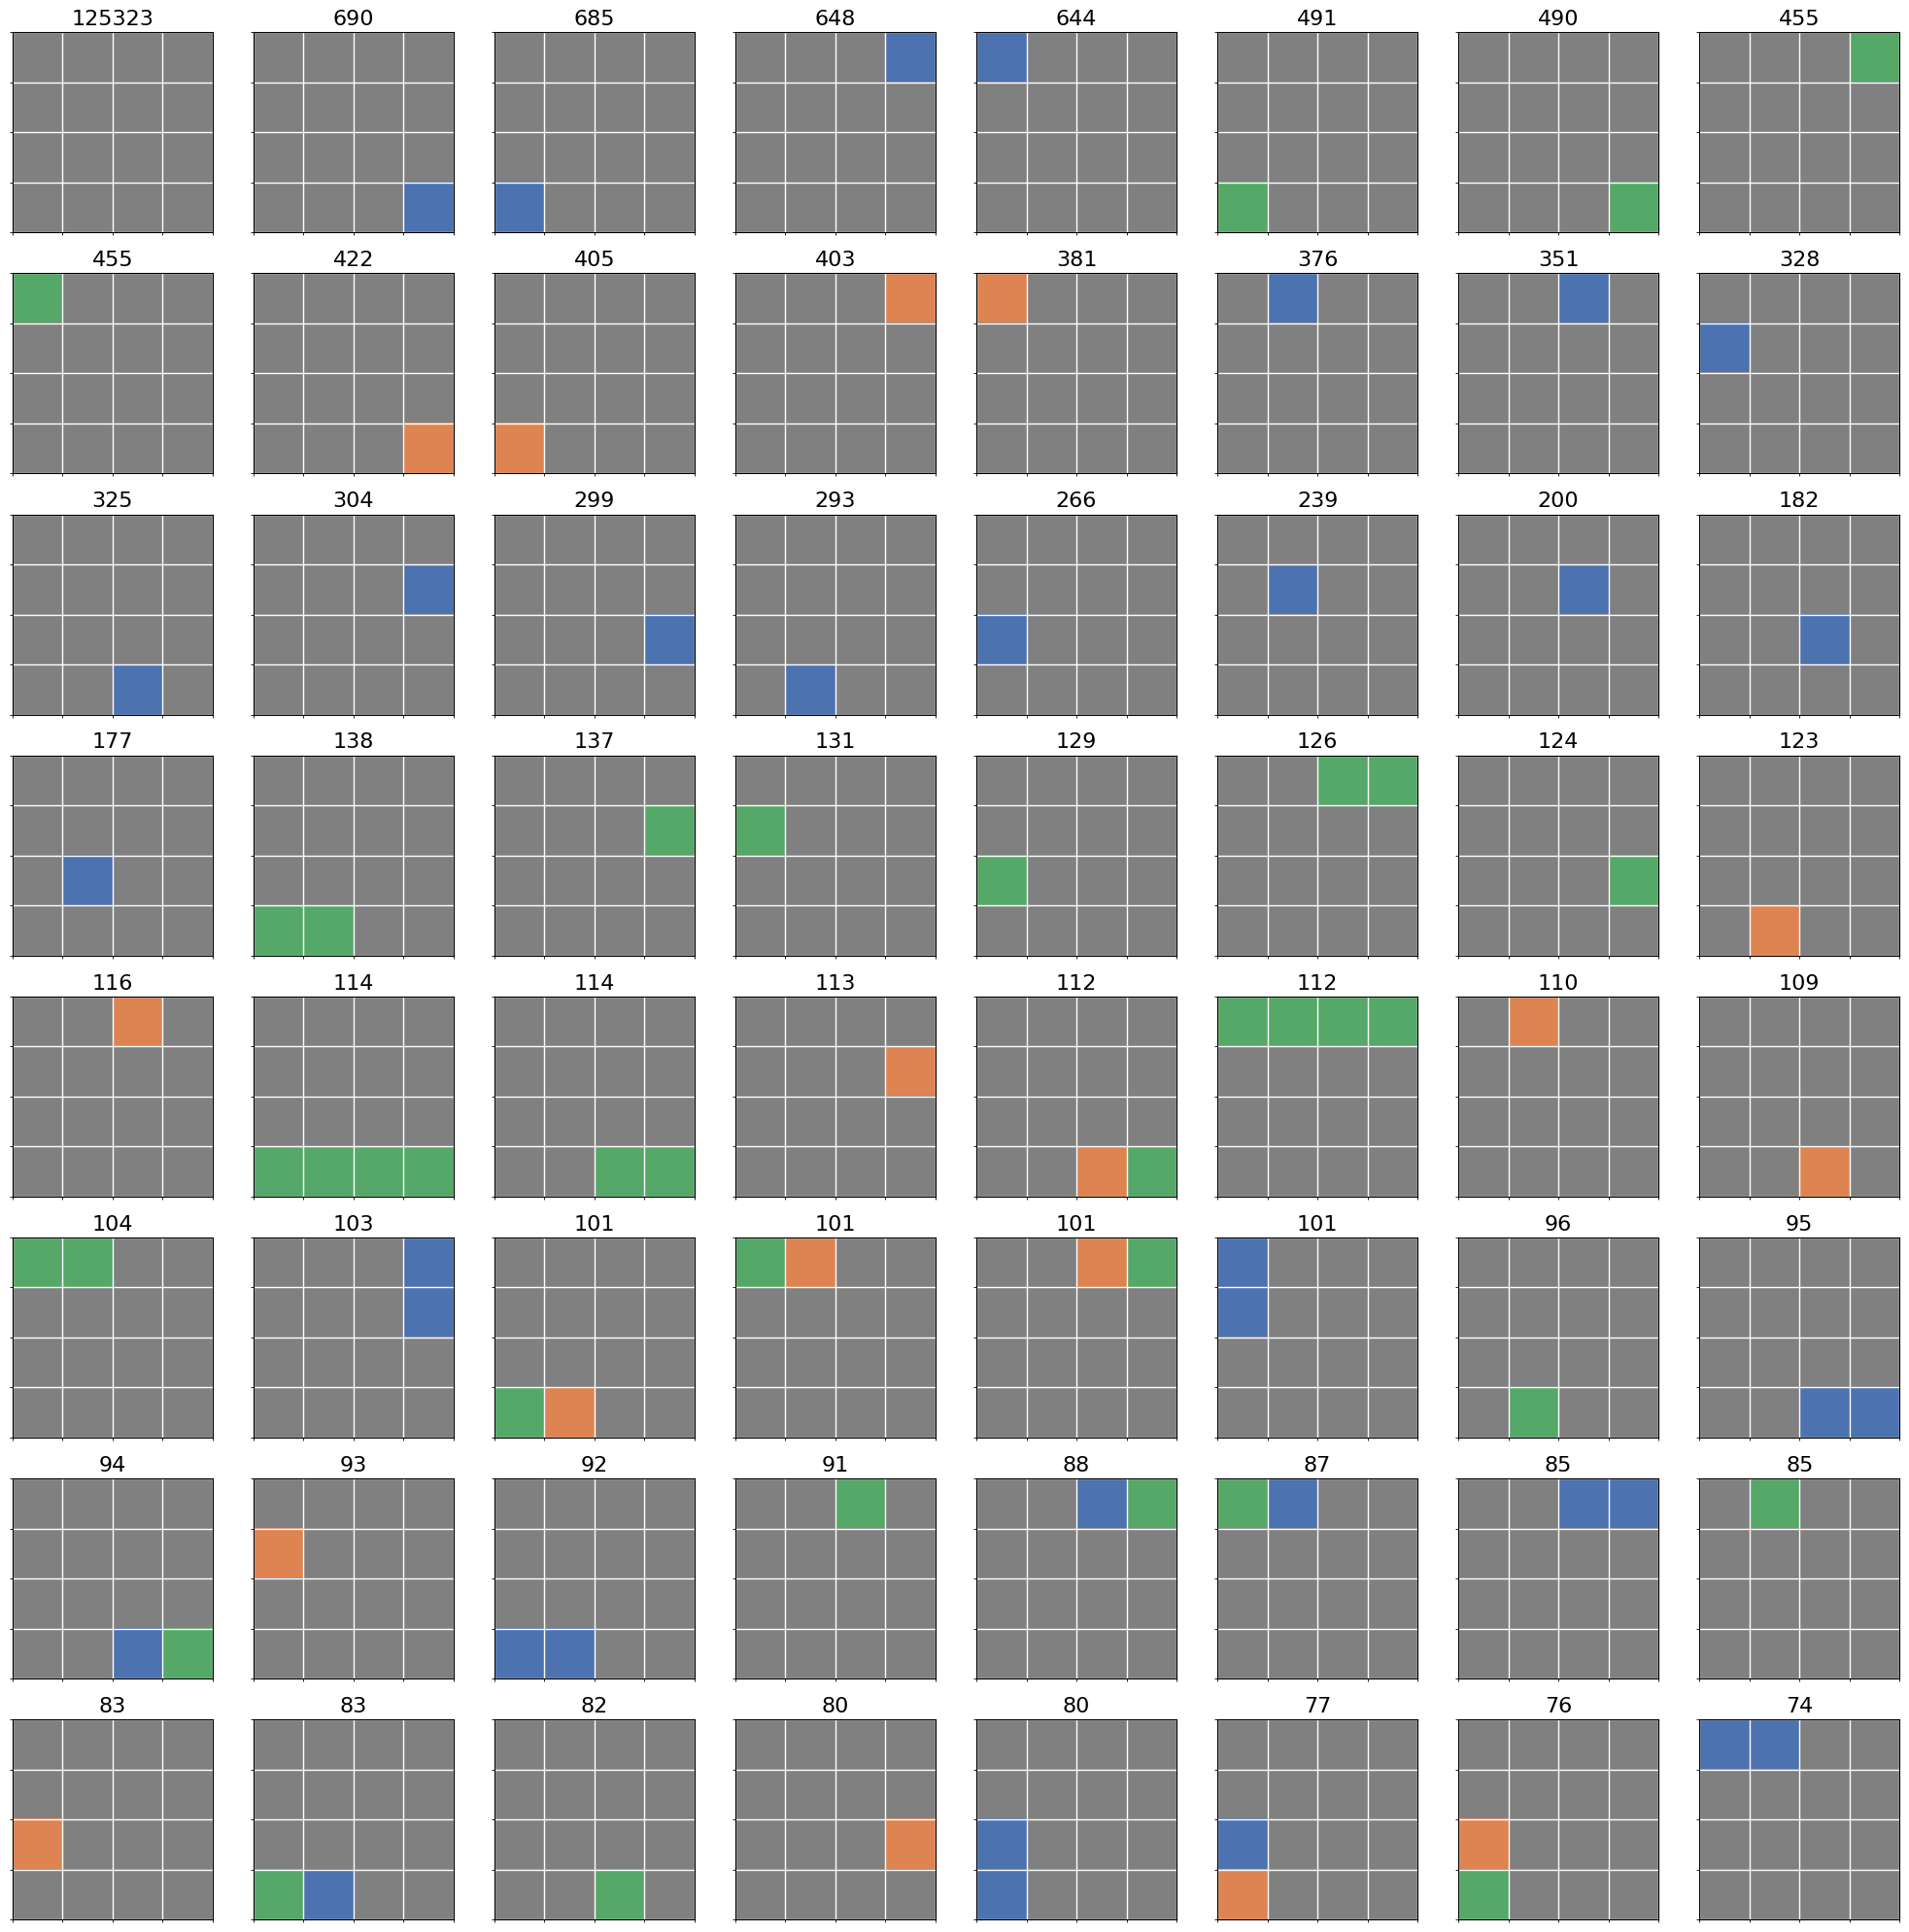

In [59]:
K = 64

from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(8, 8, figsize=(20,20))
cmap = ListedColormap(["grey", "#4C72B0", "#DD8452", "#55A868"])

for ax, (pat, cnt) in zip(axes.flat, patches_ctr.most_common(K)):
    img = np.array(pat).reshape(patch_dim)

    ax.imshow(img, cmap=cmap, vmin=0, vmax=3)

    # ---- draw pixel grid ----
    h, w = img.shape
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)

    # ---- clean axes ----
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(cnt, fontsize=16)

plt.tight_layout()
plt.show()


In [60]:
def estimate_bits_per_cell_from_topK(patches_ctr, pH, pW, K):
    """
    Simple top-K dictionary + ESC model:
      - encode symbol among (top-K patches + ESC) with ideal entropy H_sym (lower bound)
      - if ESC, transmit raw patch payload (pH*pW*bits_per_entry)

    Returns: (bits_per_cell, p_esc, H_sym_bits_per_patch)
    """
    total = sum(patches_ctr.values())  # total patch *occurrences*
    top = patches_ctr.most_common(K)
    top_counts = np.array([cnt for _, cnt in top], dtype=np.float64)

    levels = set()
    for pat, cnt in top:
        levels |= set(pat)
    n_levels = max(1, len(levels))
    bits_per_entry= np.ceil(np.log2(n_levels))
    
    p_top = top_counts / total
    p_esc = max(0.0, 1.0 - float(p_top.sum()))  # clamp for numerical safety

    # symbol distribution over K+1 symbols (K dictionary entries + ESC)
    p_sym = np.concatenate([p_top, np.array([p_esc])])
    p_nonzero = p_sym[p_sym > 0] # avoid log(0)
    H_sym = -np.sum(p_nonzero * np.log2(p_nonzero))  # bits per patch for symbol (ideal)

    raw_payload_bits = (pH * pW * bits_per_entry)  # sent only on ESC
    bits_per_patch = H_sym + p_esc * raw_payload_bits
    bits_per_cell = bits_per_patch / (pH * pW)

    return bits_per_cell, p_esc, H_sym

In [61]:
patch_dims = [(1,1), (2,2), (3,3), (4,4), (8,8)]
Ks = [8, 16, 32, 64, 128, 256, 512]

rows = []

print(f"{'patch':>9} {'K':>6} {'Keff':>6} {'bits/cell':>10} {'p_esc':>10} {'Hsym(b/patch)':>14} {'#patches':>10} {'#unique':>10}")

for (pH, pW) in patch_dims:
    patches_ctr = extract_patches(Q_int, (pH, pW), stride=None)  # non-overlapping
    npatch = sum(patches_ctr.values())
    nuniq  = len(patches_ctr)

    for K in Ks:
        K_eff = min(K, nuniq) if nuniq > 0 else 0

        bits_cell, p_esc, Hsym = estimate_bits_per_cell_from_topK(
            patches_ctr, pH, pW, K_eff
        )

        print(f"{str((pH,pW)):>9} {K:6d} {K_eff:6d} {bits_cell:10.4f} {p_esc:10.4f} {Hsym:14.4f} {npatch:10d} {nuniq:10d}")

        rows.append((pH, pW, K_eff, bits_cell, p_esc, Hsym, npatch, nuniq))


    patch      K   Keff  bits/cell      p_esc  Hsym(b/patch)   #patches    #unique
   (1, 1)      8      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     16      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     32      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     64      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    128      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    256      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    512      4     0.2973     0.0000         0.2973    2560000          4
   (2, 2)      8      8     0.2675     0.0594         0.5949     640000        256
   (2, 2)     16     16     0.2556     0.0390         0.7102     640000        256
   (2, 2)     32     32     0.2517     0.0263         0.7962     640000        256
   (2, 2)     64     64     0.2483     0.0131         0.8886     640000        256
   (

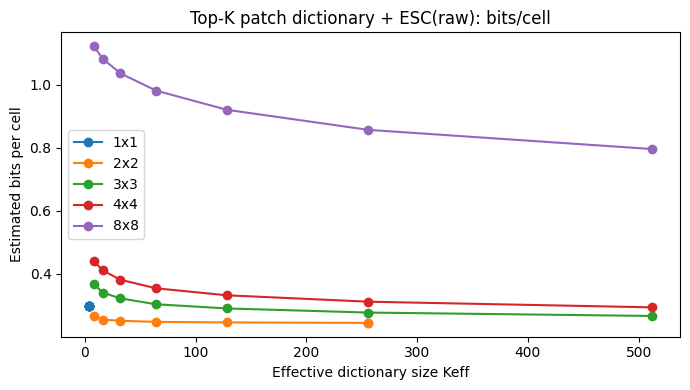

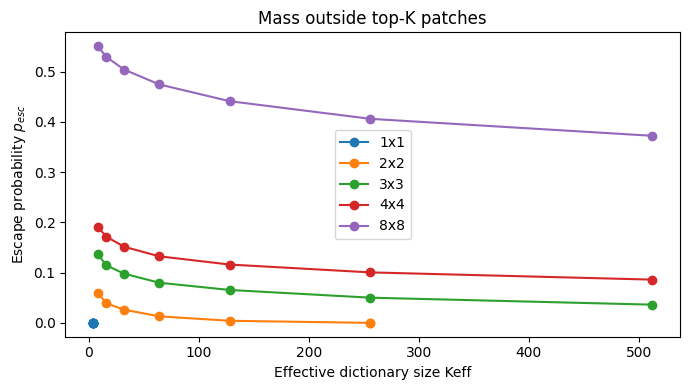

In [62]:
import pandas as pd

df = pd.DataFrame(rows, columns=["pH","pW","Keff","bits_cell","p_esc","Hsym","npatch","nuniq"])
df["patch"] = df["pH"].astype(str) + "x" + df["pW"].astype(str)

# bits/cell vs K (use original Ks on x-axis, but you stored Keff; easiest is plot vs Keff)
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["bits_cell"], marker="o", label=patch)
# plt.xscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Estimated bits per cell")
plt.title("Top-K patch dictionary + ESC(raw): bits/cell")
plt.legend()
plt.tight_layout()
plt.show()

# p_esc vs Keff
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["p_esc"], marker="o", label=patch)
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Escape probability $p_{esc}$")
plt.title("Mass outside top-K patches")
plt.legend()
plt.tight_layout()
plt.show()

# Patch ID

In [64]:
X, y = training_generator[b]
X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
Q_tf = quantizer_model(X_tf, training=False)     # hard quantize
Q_int = np.rint(Q_tf).astype(np.int8)

patch_dim = (4, 4)
unk_id=0
patches_ctr = extract_patches(Q_int, patch_dim)

In [39]:
def build_patch_dict_from_counter(patches_ctr, K, unk_id):
    """
    Returns:
      patch2id: dict patch_tuple -> id in [1..K]
      unk_id = 0
    """
    patch2id = {}
    for i, (pat, _) in enumerate(patches_ctr.most_common(K), start=1):
        patch2id[pat] = i
    return patch2id, unk_id

In [40]:
K = 16
patch2id, unk_id = build_patch_dict_from_counter(patches_ctr, K, unk_id)
vocab_size = K + 1
print(patch2id)
print(unk_id)
print(vocab_size)

{(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 1, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1): 2, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0): 3, (0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 4, (1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 5, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0): 6, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3): 7, (0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 8, (3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 9, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2): 10, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0): 11, (0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 12, (2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 13, (0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 14, (0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 15, (0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 16}
0
17


In [43]:
def tokenize_batch(Q_int, patch_dim, patch2id, stride=None, *, unk_id=0, return_coords=False):
    """
    Convert Q_int -> token sequences using a patch dictionary.

    Q_int: (B,H,W,C)
    patch_dim: (pH,pW)
    patch2id: dict {patch_tuple: id}
    stride: (dY,dX) or None -> non-overlapping
    Returns:
      tokens: (B,L) int32
      optionally coords: list of (c,y,x) or (y,x) in token order
    """
    B, H, W, C = Q_int.shape
    pH, pW = patch_dim
    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride

    # enumerate patch top-left corners the same way as extraction
    ys = list(range(0, H - pH + 1, dY))
    xs = list(range(0, W - pW + 1, dX))

    L = C * len(ys) * len(xs)
    tokens = np.empty((B, L), dtype=np.int32)
    coords = [] if return_coords else None

    idx = 0
    for c in range(C):
        for y in ys:
            for x in xs:
                if return_coords:
                    coords.append((c, y, x))
                for b in range(B):
                    patch = Q_int[b, y:y+pH, x:x+pW, c]
                    key = tuple(patch.reshape(-1).tolist())
                    tokens[b, idx] = patch2id.get(key, unk_id)
                idx += 1


    return (tokens, coords) if return_coords else tokens


In [49]:
tokens = tokenize_batch(Q_int, patch_dim, patch2id, unk_id=unk_id)  # (B, L)
seq_len = tokens.shape[1]
np.shape(tokens)

(5000, 32)

In [65]:
class TokenizedSequence(keras.utils.Sequence):
    def __init__(self, base_seq, quantizer_model, patch_dim, patch2id, unk_id=0):
        self.base = base_seq
        self.qm = quantizer_model
        self.patch_dim = patch_dim
        self.patch2id = patch2id
        self.unk_id = unk_id

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        X, y = self.base[idx]  # X: (B,16,16,2) float32, y: (B,4)
        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        Q = self.qm(X_tf, training=False)
        Q_int = tf.cast(tf.round(Q), tf.int8).numpy()
        tokens = tokenize_batch(Q_int, self.patch_dim, self.patch2id, stride=None, unk_id=self.unk_id)
        return tokens, y

In [68]:
train_tok = TokenizedSequence(training_generator, quantizer_model, patch_dim, patch2id, unk_id=unk_id)
val_tok   = TokenizedSequence(validation_generator, quantizer_model, patch_dim, patch2id, unk_id=unk_id)

t0, y0 = train_tok[0]
print("tokens:", t0.shape, t0.dtype, "y:", y0.shape, y0.dtype, "tokens min/max:", t0.min(), t0.max())

tokens: (5000, 32) int32 y: (5000, 4) <dtype: 'float32'> tokens min/max: 0 16


In [71]:
def create_LUT_model(seq_len, vocab_size, d_model=4, n_heads=4, ff=32, n_layers=2, n_outputs=14):
    tokens_in = tf.keras.layers.Input(shape=(seq_len,), dtype=tf.int32, name="patch_ids")
    tok_emb = tf.keras.layers.Embedding(vocab_size, d_model, name="tok_emb")(tokens_in)

    pos_ids = tf.range(seq_len)[None, :]
    pos_emb = tf.keras.layers.Embedding(seq_len, d_model, name="pos_emb")(pos_ids)
    x = tok_emb + pos_emb

    for i in range(n_layers):
        # Self-attn block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads)(x, x)
        x = tf.keras.layers.Add()([x0, x])

        # FFN block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.Dense(ff, activation="gelu")(x)
        x = tf.keras.layers.Dense(d_model)(x)
        x = tf.keras.layers.Add()([x0, x])

    x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # Head
    out = tf.keras.layers.Dense(n_outputs, name="head")(x)

    return tf.keras.Model(tokens_in, out)

lut_model = create_LUT_model(seq_len=seq_len, vocab_size=vocab_size, n_outputs=14)

lut_model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

lut_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patch_ids           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tok_emb (Embedding) │ (None, 32, 4)     │         68 │ patch_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 32, 4)     │          0 │ tok_emb[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 4)     │          8 │ add_30[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 4)     │         80 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 32, 4)     │          0 │ add_30[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 4)     │          8 │ add_31[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32, 32)    │        160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32, 4)     │        132 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 32, 4)     │          0 │ add_31[0][0],     │
│                     │                   │            │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 4)     │          8 │ add_32[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 4)     │         80 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_33 (Add)        │ (None, 32, 4)     │          0 │ add_32[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 4)     │          8 │ add_33[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32, 32)    │        160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 32, 4)     │        132 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 32, 4)     │          0 │ add_33[0][0],     │
│                     │                   │            │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 4)     │          8 │ add_34[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 4)         │          0 │ layer_normalizat

 Total params: 922 (3.60 KB)

 Trainable params: 922 (3.60 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_LUT_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, "weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5")

In [78]:
# 9f5e5c2c : 1000 epochs
print(checkpoint_filepath)
print(fingerprint)

./trained_LUT_models/model-4d253ca6-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5
4d253ca6


In [79]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [ ]:
history = lut_model.fit(
    train_tok,
    validation_data=val_tok,
    callbacks=[mcp, csv_logger, es],
    epochs=1000,
    verbose=1
)
